<a href="https://colab.research.google.com/github/Somalin2004/Celebal_internship/blob/main/week3_somalin_samal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Week 3 Assignment

**Assignment Topic:** Develop a Customer Intelligence System using classification, ensemble & clustering.

Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

**Resources:**

1. https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data
2. https://www.kaggle.com/code/jatin2bagga/unsupervised-learning-on-country-data

#### Import Libraries And Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv("/content/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


#### Data Preprocessing
Understanding The Data

In [ ]:
print(df.shape)
df.info()
df.describe()
print(df.isnull().sum())

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Encode Country Names

In [ ]:
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])

Create Target Variable

In [ ]:
median_income = df['income'].median()
df['Target'] = np.where(df['income'] >= median_income,1,0)

Features And Target

In [ ]:
X = df.drop('Target',axis=1)
y = df['Target']

Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

Standard Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Exploratory Data Analysis
Data Print

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Target
0,0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


Correlation


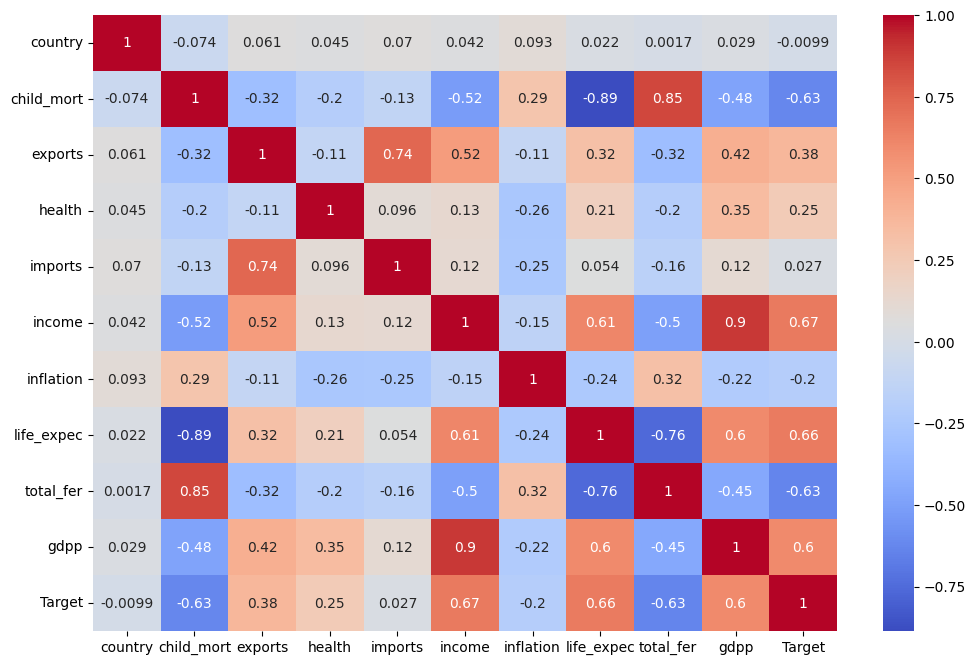

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

Histograms

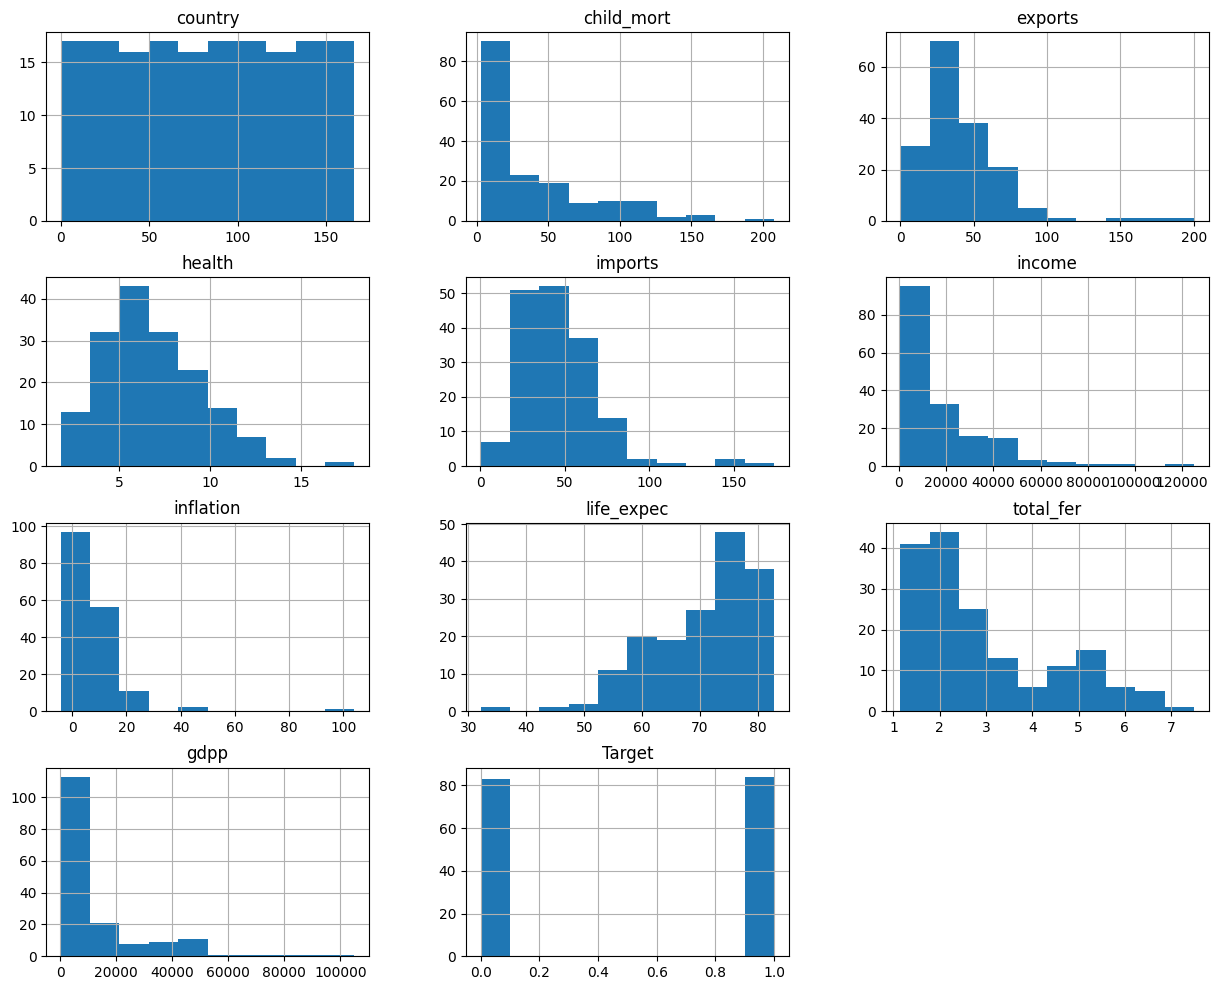

In [ ]:
df.hist(figsize=(15,12))
plt.show()

Pairplot

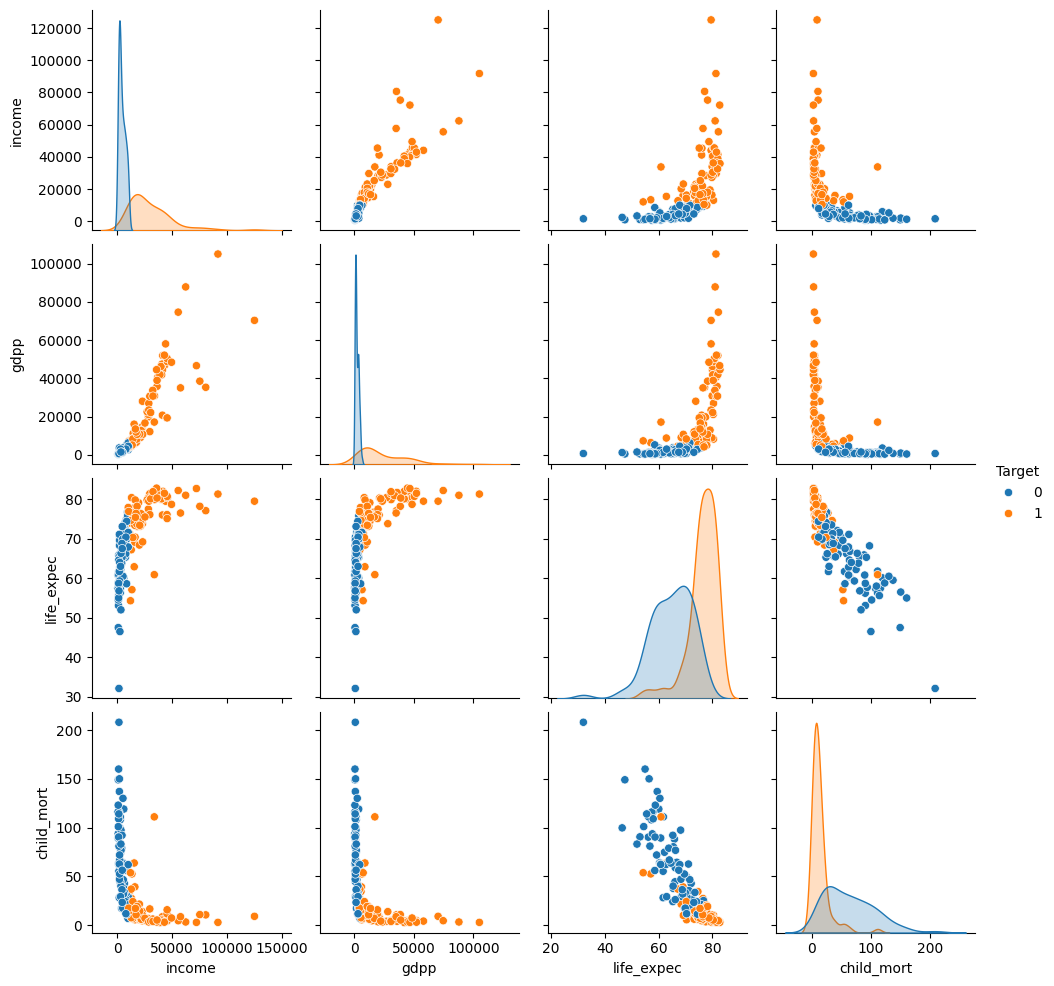

In [ ]:
sns.pairplot(df[['income','gdpp','life_expec','child_mort','Target']],hue='Target')
plt.show()

#### Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_lr))
print(classification_report(y_test,pred_lr))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
pred_knn = knn.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_knn))
print(classification_report(y_test,pred_knn))

Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

           0       0.94      0.83      0.88        18
           1       0.83      0.94      0.88        16

    accuracy                           0.88        34
   macro avg       0.89      0.89      0.88        34
weighted avg       0.89      0.88      0.88        34



SVM

In [ ]:
svm = SVC()
svm.fit(X_train,y_train)
pred_svm = svm.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_svm))
print(classification_report(y_test,pred_svm))

Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.94      0.97        16

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_dt))
print(classification_report(y_test,pred_dt))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_rf))
print(classification_report(y_test,pred_rf))

Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.94      1.00      0.97        16

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



AdaBoost

In [ ]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train,y_train)
pred_ada = ada.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_ada))
print(classification_report(y_test,pred_ada))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



#### Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train,y_train)
pred_gb = gb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_gb))
print(classification_report(y_test,pred_gb))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



XGBoost

In [ ]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train,y_train)
pred_xgb = xgb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_xgb))
print(classification_report(y_test,pred_xgb))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



#### Stacking Classifier

In [ ]:
estimators = [
    ('rf',RandomForestClassifier()),
    ('dt',DecisionTreeClassifier()),
    ('knn',KNeighborsClassifier())
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)
stack.fit(X_train,y_train)
pred_stack = stack.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_stack))
print(classification_report(y_test,pred_stack))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



Feature Importance

      Feature  Importance
5      income    0.402142
9        gdpp    0.323272
7  life_expec    0.093329
1  child_mort    0.069591
8   total_fer    0.052505
6   inflation    0.019429
2     exports    0.018144
3      health    0.011415
0     country    0.006851
4     imports    0.003322


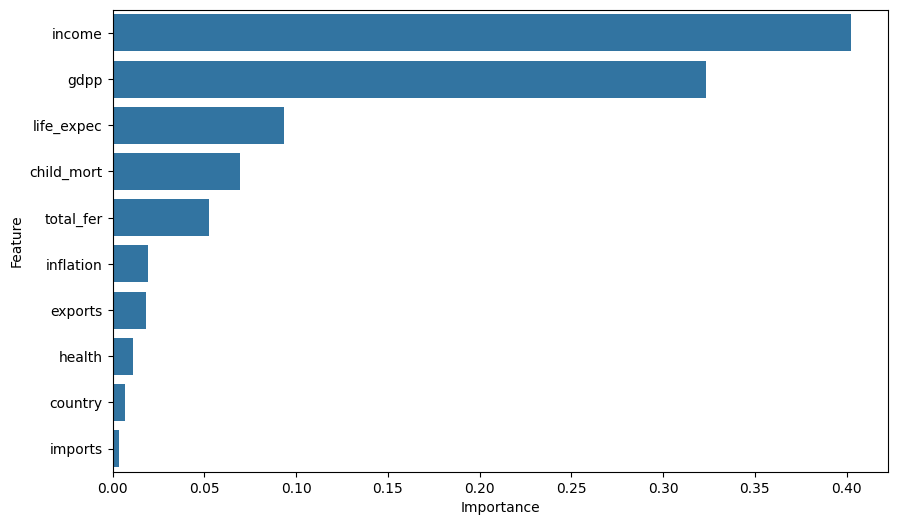

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.show()

K-Means

In [ ]:
X_cluster = scaler.fit_transform(X)
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
clusters = kmeans.fit_predict(X_cluster)
df['KMeans'] = clusters
print(df[['country','KMeans']].head())

   country  KMeans
0        0       0
1        1       2
2        2       2
3        3       0
4        4       2


DBSCAN

In [ ]:
db = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_clusters = db.fit_predict(X_cluster)
df['DBSCAN'] = db_clusters
print(df[['country','DBSCAN']].head())

   country  DBSCAN
0        0       0
1        1       0
2        2       0
3        3      -1
4        4       0


#### Hierarchical Clustering

In [ ]:
hc = AgglomerativeClustering(
    n_clusters=3
)

hc_clusters = hc.fit_predict(X_cluster)
df['Hierarchical'] = hc_clusters
print(df[['country','Hierarchical']].head())

   country  Hierarchical
0        0             1
1        1             2
2        2             2
3        3             1
4        4             2


#### Model Comparison

                 Model  Accuracy
0  Logistic Regression  1.000000
3        Decision Tree  1.000000
7              XGBoost  1.000000
6    Gradient Boosting  1.000000
5             AdaBoost  1.000000
8             Stacking  1.000000
2                  SVM  0.970588
4        Random Forest  0.970588
1                  KNN  0.882353 



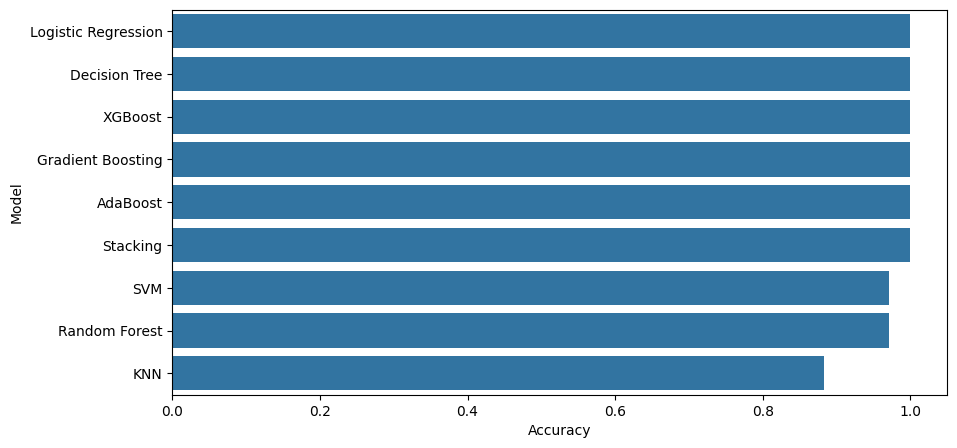

In [ ]:
results = pd.DataFrame({
'Model':[
'Logistic Regression',
'KNN',
'SVM',
'Decision Tree',
'Random Forest',
'AdaBoost',
'Gradient Boosting',
'XGBoost',
'Stacking'
],
'Accuracy':[
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_knn),
accuracy_score(y_test,pred_svm),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_ada),
accuracy_score(y_test,pred_gb),
accuracy_score(y_test,pred_xgb),
accuracy_score(y_test,pred_stack)
]
})

results = results.sort_values(
    by='Accuracy',
    ascending=False
)
print(results,"\n")
plt.figure(figsize=(10,5))
sns.barplot(
    x='Accuracy',
    y='Model',
    data=results
)
plt.show()

#### Conclusion

In [ ]:
best_model = results.iloc[0]

print("Best Model :", best_model['Model'])
print("Accuracy :", best_model['Accuracy'])

Best Model : Logistic Regression
Accuracy : 1.0


Conclusion:

1. Multiple classification models were trained.
2. Ensemble methods generally performed better.
3. Feature importance identified the most influential variables.
4. K-Means, DBSCAN, and Hierarchical clustering successfully segmented countries.
5. The developed Customer Intelligence System can support customer segmentation and predictive analytics.

---
## 🏁 Submission Checklist

- ✅ Markdown are used with proper description.
- ✅ All plots render with labels and titles.
- ✅ Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)
